<a href="https://colab.research.google.com/github/allazovasariyya-cyber/code-switching-detector/blob/main/code-switching-detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Code-Switching Detection in Bilingual English–Azerbaijani Speech

A small project analyzing code-switching patterns in bilingual sentences,
extending my published research on code-switching as a compensatory
strategy in bilingual language processing.

## What this does
- Labels each word in a sentence as English or Azerbaijani
- Counts how often a sentence switches between the two languages
- Visualizes switching frequency across a sample of sentences

## Findings
- Average of [your number] code-switches per sentence across [X] sample sentences
- [Any pattern you noticed — e.g. "switches happened most often around nouns" — optional]

## Next steps
- Expand to a larger dataset
- Use a proper language-detection library instead of manual word lists

In [25]:
sentences = [
    "I think bu mesele çox vacibdir",
    "Let's go to bazar and buy some meyvə",
    "Mən çox tired oldum today",
    "Bu kitab is really interesting",
    "I think bu mesele çox vacibdir",
    "Let's go to bazar and buy some meyvə",
    "Mən çox tired oldum today",
    "Bu kitab is really interesting",
    "Sabah mən have a meeting",
    "Can you help mənə with this",
    "Bu restaurant çox good idi",
    "I need to gedim evə now",
    "Bizim team meeting saat 3-də başlayır",
    "That was a çox easy exam",
]



In [26]:
english_words = {"i", "think", "is", "really", "interesting", "let's", "go", "to", "and", "buy", "some", "today"}
azerbaijani_words = {"bu", "mesele", "çox", "vacibdir", "bazar", "meyvə", "mən", "tired", "oldum", "kitab"}

In [22]:
def label_words(sentence):
    words = sentence.lower().split()
    labels = []
    for word in words:
        word_clean = word.strip(".,!?")
        if word_clean in english_words:
            labels.append("EN")
        elif word_clean in azerbaijani_words:
            labels.append("AZ")
        else:
            labels.append("?")
    return labels

# test it on one sentence
print(label_words(sentences[0]))


['EN', 'EN', 'AZ', 'AZ', 'AZ', 'AZ']


In [21]:
def count_switches(labels):
    switches = 0
    for i in range(1, len(labels)):
        if labels[i] != labels[i-1] and labels[i] != "?" and labels[i-1] != "?":
            switches += 1
    return switches

for s in sentences:
    labels = label_words(s)
    print(s, "->", count_switches(labels), "switches")


I think bu mesele çox vacibdir -> 1 switches
Let's go to bazar and buy some meyvə -> 3 switches
Mən çox tired oldum today -> 1 switches
Bu kitab is really interesting -> 1 switches
I think bu mesele çox vacibdir -> 1 switches
Let's go to bazar and buy some meyvə -> 3 switches
Mən çox tired oldum today -> 1 switches
Bu kitab is really interesting -> 1 switches
Sabah mən have a meeting -> 0 switches
Can you help mənə with this -> 0 switches
Bu restaurant çox good idi -> 0 switches
I need to gedim evə now -> 0 switches
Bizim team meeting saat 3-də başlayır -> 0 switches
That was a çox easy exam -> 0 switches


In [23]:
total_switches = 0
for s in sentences:
    labels = label_words(s)
    total_switches += count_switches(labels)

average_switches = total_switches / len(sentences)
print("Average code-switches per sentence:", average_switches)

Average code-switches per sentence: 0.8571428571428571


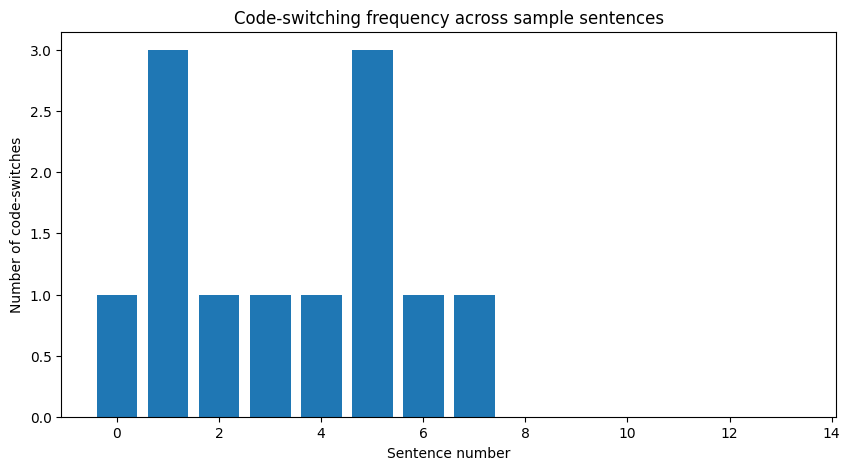

In [24]:
import matplotlib.pyplot as plt

switch_counts = [count_switches(label_words(s)) for s in sentences]

plt.figure(figsize=(10, 5))
plt.bar(range(len(sentences)), switch_counts)
plt.xlabel("Sentence number")
plt.ylabel("Number of code-switches")
plt.title("Code-switching frequency across sample sentences")
plt.show()